In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else "cpu")

In [3]:
torch.manual_seed(42)

In [4]:
import os

CSV_PATH = '/content/sample_data/mnist_train_small.csv'

if not os.path.exists(CSV_PATH):
    # Fallback for environments outside Google Colab (no bundled sample_data dir)
    from sklearn.datasets import fetch_openml

    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    df = pd.DataFrame(mnist.data[:20000])
    df.insert(0, 'label', mnist.target[:20000].astype(int))
else:
    df = pd.read_csv(CSV_PATH)

df.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


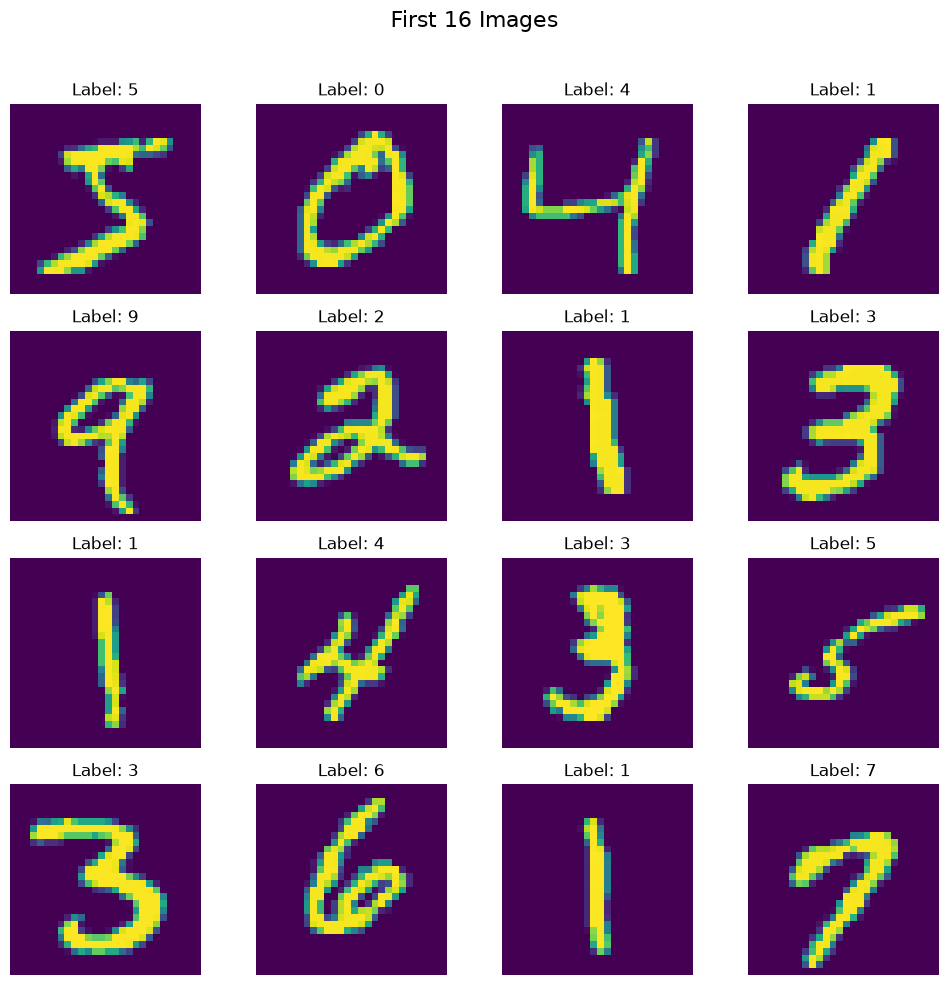

In [5]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [6]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [7]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
X_train=X_train/255.0
X_test=X_test/255.0

In [9]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
      return len(self.features)
  def __getitem__(self, index):
      return self.features[index], self.labels[index]


In [10]:
train_dataset=CustomDataset(X_train,y_train)

In [11]:
test_dataset=CustomDataset(X_test,y_test)

In [12]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

In [13]:
# objective function
def objective(trial):

  # next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()
  # evaluation on test data
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct/total

  return accuracy

In [14]:
import optuna

study=optuna.create_study(direction="maximize")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-10-03 18:51:41,657] A new study created in memory with name: no-name-e4ae82c9-a5b9-43bf-94be-496619728a4d


In [15]:
study.optimize(objective,n_trials=3)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[I 2026-10-03 18:51:51,433] Trial 0 finished with value: 0.93875 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 40, 'epochs': 10, 'learning_rate': 0.016308666968454715, 'dropout_rate': 0.2, 'batch_size': 16, 'optimizer': 'RMSprop', 'weight_decay': 1.3892695799304932e-05}. Best is trial 0 with value: 0.93875.


[I 2026-10-03 18:51:53,031] Trial 1 finished with value: 0.9545 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 32, 'epochs': 10, 'learning_rate': 0.005213568719807743, 'dropout_rate': 0.1, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0002470325703239132}. Best is trial 1 with value: 0.9545.


[I 2026-10-03 18:52:08,576] Trial 2 finished with value: 0.973 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 104, 'epochs': 30, 'learning_rate': 0.0180272822226512, 'dropout_rate': 0.1, 'batch_size': 16, 'optimizer': 'SGD', 'weight_decay': 0.00016036079152766832}. Best is trial 2 with value: 0.973.


In [16]:
study.best_value

0.973

In [17]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 104,
 'epochs': 30,
 'learning_rate': 0.0180272822226512,
 'dropout_rate': 0.1,
 'batch_size': 16,
 'optimizer': 'SGD',
 'weight_decay': 0.00016036079152766832}